
# Task 2 — MOMENT Foundation Model + Trainable MLP Head (Aligned Protocol)

This notebook adds **MOMENT-1-base** as a general-purpose time-series foundation-model baseline for Task 2.

## Protocol aligned with the existing Task 2 models

- same canonical dataset
- same 7-hour window: `t-3 ... t+3`
- same two channels:
  1. `log1p(flow)`
  2. pre-event-normalized relative change
- same classes: `NORMAL`, `ACCIDENT`, `OTHER_DISRUPTION`
- same grouped-random and spatial-holdout manifests
- same seeds: `42, 52, 62`
- Macro-F1 as the primary metric
- validation-only model/configuration selection
- final test evaluation only after validation selection
- final results reported as mean ± SD across three seeds

## MOMENT-specific adaptation

MOMENT-1 uses a context length of 512. The original Task 2 sequence has only 7 hourly steps, so the
7-step sequence is interpolated to 512 steps before embedding. This does **not** add new information;
it only adapts the short sequence to the pretrained model's expected input length.

The pretrained MOMENT encoder is used as a frozen representation model. A small supervised MLP head
is trained on the resulting embeddings using the same neural training protocol as the aligned Task 2
models.

Recommended paper label:

**MOMENT-1-base (pretrained frozen encoder + supervised MLP head)**


In [1]:
import sys
print(sys.version)

3.11.15 (main, Jun 11 2026, 15:14:57) [Clang 20.1.8 ]


In [2]:
from momentfm import MOMENTPipeline
print("MOMENT ready")

MOMENT ready


/opt/anaconda3/envs/moment311/lib/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [3]:

# Run once if needed.
# MOMENT currently recommends Python 3.11.

%pip install -q momentfm scikit-learn pandas numpy matplotlib torch transformers huggingface_hub


Note: you may need to restart the kernel to use updated packages.


In [4]:

from pathlib import Path
import copy
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

SEEDS = [42, 52, 62]

CLASS_ORDER = ["NORMAL", "ACCIDENT", "OTHER_DISRUPTION"]
CLASS_TO_ID = {
    "NORMAL": 0,
    "ACCIDENT": 1,
    "OTHER_DISRUPTION": 2,
}

# ============================================================
# EDIT ONLY IF YOUR PATHS DIFFER
# ============================================================
BASE_DIR = Path.home() / "Downloads"

DATA_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/canonical_dataset_revised.csv")
GROUPED_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/grouped_random_split_manifest_revised.csv")
SPATIAL_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/spatial_split_manifest_revised.csv")
# MOMENT model
MOMENT_CHECKPOINT = "AutonLab/MOMENT-1-base"
MOMENT_LENGTH = 512

# Aligned neural training protocol
MAX_EPOCHS = 35
BATCH_SIZE = 64
PATIENCE = 6
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0

# Small validation grid for the downstream classification head.
HEAD_CONFIGS = [
    {"hidden": 64, "dropout": 0.20, "lr": 1e-3},
    {"hidden": 128, "dropout": 0.30, "lr": 5e-4},
]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
print("MOMENT checkpoint:", MOMENT_CHECKPOINT)


Device: cpu
MOMENT checkpoint: AutonLab/MOMENT-1-base


## 1. Helpers

In [5]:

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def first_existing(columns, candidates):
    lower_map = {str(c).lower(): c for c in columns}

    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]

    return None


## 2. Preflight file check

In [6]:

paths = {
    "canonical": DATA_PATH,
    "grouped_manifest": GROUPED_MANIFEST_PATH,
    "spatial_manifest": SPATIAL_MANIFEST_PATH,
}

for name, path in paths.items():
    print(f"{name}: {path} | exists={path.exists()}")

missing_paths = [str(path) for path in paths.values() if not path.exists()]

if missing_paths:
    raise FileNotFoundError(
        "Missing required files:\n" + "\n".join(missing_paths)
    )

resolved = [str(path.resolve()) for path in paths.values()]

if len(set(resolved)) != 3:
    raise ValueError(
        "Canonical dataset, grouped manifest, and spatial manifest must be "
        "three different CSV files."
    )


canonical: /Users/andishahifahmuthahharah/Downloads/revised_core_dataset_final/canonical_dataset_revised.csv | exists=True
grouped_manifest: /Users/andishahifahmuthahharah/Downloads/revised_core_dataset_final/grouped_random_split_manifest_revised.csv | exists=True
spatial_manifest: /Users/andishahifahmuthahharah/Downloads/revised_core_dataset_final/spatial_split_manifest_revised.csv | exists=True


## 3. Load canonical dataset and frozen split manifests

In [7]:

df = pd.read_csv(DATA_PATH)
grouped_manifest = pd.read_csv(GROUPED_MANIFEST_PATH)
spatial_manifest = pd.read_csv(SPATIAL_MANIFEST_PATH)

print("Canonical:", df.shape)
print("Grouped manifest:", grouped_manifest.shape)
print("Spatial manifest:", spatial_manifest.shape)

print("\nCanonical columns:")
print(df.columns.tolist())

print("\nGrouped manifest columns:")
print(grouped_manifest.columns.tolist())

print("\nSpatial manifest columns:")
print(spatial_manifest.columns.tolist())

display(df.head())
display(grouped_manifest.head())
display(spatial_manifest.head())


Canonical: (5265, 16)
Grouped manifest: (5265, 5)
Spatial manifest: (5265, 5)

Canonical columns:
['event_sample_id', 'station_id', 'anchor_time', 'window_start', 'window_end', 'target_class', 'split_group_id', 'sample_type', 'flow_t_minus_3', 'flow_t_minus_2', 'flow_t_minus_1', 'flow_t0', 'flow_t_plus_1', 'flow_t_plus_2', 'flow_t_plus_3', 'all_zero_flow_window']

Grouped manifest columns:
['event_sample_id', 'split_group_id', 'station_id', 'target_class', 'split']

Spatial manifest columns:
['event_sample_id', 'split_group_id', 'station_id', 'target_class', 'split']


,event_sample_id,station_id,anchor_time,window_start,window_end,target_class,split_group_id,sample_type,flow_t_minus_3,flow_t_minus_2,flow_t_minus_1,flow_t0,flow_t_plus_1,flow_t_plus_2,flow_t_plus_3,all_zero_flow_window
0,INCIDENT__219427-webtirf__7120,7120,2025-01-01 04:00:00,2025-01-01 01:00:00,2025-01-01 07:00:00,OTHER_DISRUPTION,GROUP__7120__0001,INCIDENT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
1,INCIDENT__219427-webtirf__7121,7121,2025-01-01 04:00:00,2025-01-01 01:00:00,2025-01-01 07:00:00,OTHER_DISRUPTION,GROUP__7121__0001,INCIDENT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
2,INCIDENT__219440.0-webtirf__7168,7168,2025-01-01 11:00:00,2025-01-01 08:00:00,2025-01-01 14:00:00,OTHER_DISRUPTION,GROUP__7168__0001,INCIDENT,13.0,4.0,13.0,10.0,16.0,12.0,7.0,False
3,INCIDENT__219468-webtirf__F3FWY003,F3FWY003,2025-01-02 01:00:00,2025-01-01 22:00:00,2025-01-02 04:00:00,ACCIDENT,GROUP__F3FWY003__0001,INCIDENT,0.0,0.0,31.0,19.0,30.0,27.0,0.0,False
4,INCIDENT__219481-webtirf__7179,7179,2025-01-02 03:00:00,2025-01-02 00:00:00,2025-01-02 06:00:00,OTHER_DISRUPTION,GROUP__7179__0001,INCIDENT,21.0,30.0,33.0,34.0,73.0,105.0,160.0,False


,event_sample_id,split_group_id,station_id,target_class,split
0,INCIDENT__219427-webtirf__7120,GROUP__7120__0001,7120,OTHER_DISRUPTION,train
1,INCIDENT__219427-webtirf__7121,GROUP__7121__0001,7121,OTHER_DISRUPTION,test
2,INCIDENT__219440.0-webtirf__7168,GROUP__7168__0001,7168,OTHER_DISRUPTION,train
3,INCIDENT__219468-webtirf__F3FWY003,GROUP__F3FWY003__0001,F3FWY003,ACCIDENT,validation
4,INCIDENT__219481-webtirf__7179,GROUP__7179__0001,7179,OTHER_DISRUPTION,validation


,event_sample_id,split_group_id,station_id,target_class,split
0,INCIDENT__219427-webtirf__7120,GROUP__7120__0001,7120,OTHER_DISRUPTION,train
1,INCIDENT__219427-webtirf__7121,GROUP__7121__0001,7121,OTHER_DISRUPTION,validation
2,INCIDENT__219440.0-webtirf__7168,GROUP__7168__0001,7168,OTHER_DISRUPTION,train
3,INCIDENT__219468-webtirf__F3FWY003,GROUP__F3FWY003__0001,F3FWY003,ACCIDENT,test
4,INCIDENT__219481-webtirf__7179,GROUP__7179__0001,7179,OTHER_DISRUPTION,train


## 4. Build the aligned 7 × 2 Task 2 sequence

In [8]:

LABEL_COL = first_existing(
    df.columns,
    [
        "target_class",
        "label",
        "class",
        "target",
        "incident_class",
        "task2_class",
        "condition",
    ],
)

FLOW_COLUMNS = [
    "flow_t_minus_3",
    "flow_t_minus_2",
    "flow_t_minus_1",
    "flow_t0",
    "flow_t_plus_1",
    "flow_t_plus_2",
    "flow_t_plus_3",
]

if LABEL_COL is None:
    raise ValueError(
        f"Task 2 target column not found. Available columns: {list(df.columns)}"
    )

missing_flow_cols = [c for c in FLOW_COLUMNS if c not in df.columns]

if missing_flow_cols:
    raise ValueError(
        f"Missing Task 2 flow columns: {missing_flow_cols}"
    )

print("Target column:", LABEL_COL)
print(df[LABEL_COL].value_counts(dropna=False))


Target column: target_class
target_class
NORMAL              3581
OTHER_DISRUPTION    1179
ACCIDENT             505
Name: count, dtype: int64


In [9]:

def build_two_channel_input(frame, flow_columns):
    flow = frame[flow_columns].astype(float).to_numpy()

    if np.any(~np.isfinite(flow)):
        raise ValueError("Non-finite flow values found in the 7-hour window.")

    # Channel 1: log-transformed flow
    channel_1 = np.log1p(np.clip(flow, 0, None))

    # Channel 2: pre-event-normalized relative change
    # B = median(t-3, t-2, t-1)
    baseline = np.median(flow[:, :3], axis=1, keepdims=True)

    channel_2 = (flow - baseline) / (baseline + 1.0)
    channel_2 = np.clip(channel_2, -5.0, 5.0)

    # [N, C, L] = [N, 2, 7]
    return np.stack(
        [channel_1, channel_2],
        axis=1,
    ).astype(np.float32)


X7 = build_two_channel_input(df, FLOW_COLUMNS)

labels = (
    df[LABEL_COL]
    .astype(str)
    .str.upper()
    .str.strip()
)

unknown_labels = sorted(set(labels) - set(CLASS_ORDER))

if unknown_labels:
    raise ValueError(
        f"Unexpected labels: {unknown_labels}. "
        f"Expected only {CLASS_ORDER}."
    )

y = labels.map(CLASS_TO_ID).to_numpy(dtype=np.int64)

print("X7 shape:", X7.shape)
print("y shape:", y.shape)
print("Class mapping:", CLASS_TO_ID)

for class_name in CLASS_ORDER:
    print(class_name, int((labels == class_name).sum()))


X7 shape: (5265, 2, 7)
y shape: (5265,)
Class mapping: {'NORMAL': 0, 'ACCIDENT': 1, 'OTHER_DISRUPTION': 2}
NORMAL 3581
ACCIDENT 505
OTHER_DISRUPTION 1179


## 5. Adapt the 7-step sequence to MOMENT length 512

In [10]:

def resize_for_moment(X, target_length=MOMENT_LENGTH):
    if X.ndim != 3:
        raise ValueError(
            f"Expected [N, C, L], received shape {X.shape}"
        )

    tensor = torch.as_tensor(
        X,
        dtype=torch.float32,
    )

    resized = F.interpolate(
        tensor,
        size=target_length,
        mode="linear",
        align_corners=False,
    )

    return resized.numpy().astype(np.float32)


X_moment = resize_for_moment(X7)

print("Original Task 2 input:", X7.shape)
print("MOMENT-ready input:", X_moment.shape)


Original Task 2 input: (5265, 2, 7)
MOMENT-ready input: (5265, 2, 512)


## 6. Resolve train / validation / test indices

In [11]:

def normalize_split_name(value):
    value = str(value).strip().lower()

    mapping = {
        "train": "train",
        "training": "train",
        "val": "val",
        "valid": "val",
        "validation": "val",
        "test": "test",
        "testing": "test",
    }

    return mapping.get(value, value)


def resolve_manifest_indices(
    dataframe,
    manifest,
    manifest_name="manifest",
):
    split_col = first_existing(
        manifest.columns,
        ["split", "partition", "set", "subset", "split_name"],
    )

    if split_col is None:
        raise ValueError(
            f"{manifest_name} has no split column. "
            f"Loaded columns: {list(manifest.columns)}"
        )

    data_id_col = first_existing(
        dataframe.columns,
        [
            "event_sample_id",
            "sample_id",
            "id",
            "window_id",
            "record_id",
        ],
    )

    manifest_id_col = first_existing(
        manifest.columns,
        [
            "event_sample_id",
            "sample_id",
            "id",
            "window_id",
            "record_id",
        ],
    )

    m = manifest.copy()
    m["_split"] = m[split_col].map(normalize_split_name)

    if data_id_col is not None and manifest_id_col is not None:

        if dataframe[data_id_col].astype(str).duplicated().any():
            raise ValueError(
                f"`{data_id_col}` must be unique in canonical data."
            )

        lookup = pd.Series(
            np.arange(len(dataframe)),
            index=dataframe[data_id_col].astype(str),
        )

        ids = m[manifest_id_col].astype(str)

        missing_ids = ids[~ids.isin(lookup.index)]

        if len(missing_ids) > 0:
            raise ValueError(
                f"{manifest_name}: {len(missing_ids)} sample IDs "
                "were not found in canonical data."
            )

        m["_idx"] = ids.map(lookup).astype(int)

    else:

        if len(m) != len(dataframe):
            raise ValueError(
                f"{manifest_name}: no shared sample ID found "
                "and row counts differ."
            )

        m["_idx"] = np.arange(len(dataframe))

    output = {
        split: m.loc[
            m["_split"] == split,
            "_idx",
        ].to_numpy(dtype=int)
        for split in ["train", "val", "test"]
    }

    counts = {
        key: len(value)
        for key, value in output.items()
    }

    if any(count == 0 for count in counts.values()):
        raise ValueError(
            f"{manifest_name}: empty split detected: {counts}. "
            f"Raw split values: "
            f"{sorted(manifest[split_col].astype(str).unique())}"
        )

    return output


grouped_idx = resolve_manifest_indices(
    df,
    grouped_manifest,
    "grouped_random_split_manifest_revised.csv",
)

spatial_idx = resolve_manifest_indices(
    df,
    spatial_manifest,
    "spatial_split_manifest_revised.csv",
)

print(
    "Grouped:",
    {key: len(value) for key, value in grouped_idx.items()},
)

print(
    "Spatial:",
    {key: len(value) for key, value in spatial_idx.items()},
)


Grouped: {'train': 3685, 'val': 784, 'test': 796}
Spatial: {'train': 3703, 'val': 806, 'test': 756}


## 7. Load pretrained MOMENT-1-base in embedding mode

In [12]:

from momentfm import MOMENTPipeline

set_seed(42)

moment_model = MOMENTPipeline.from_pretrained(
    MOMENT_CHECKPOINT,
    model_kwargs={
        "task_name": "embedding",
    },
)

moment_model.init()
moment_model = moment_model.to(DEVICE)
moment_model.eval()

print("Loaded:", MOMENT_CHECKPOINT)


Loaded: AutonLab/MOMENT-1-base



## 8. Extract pretrained MOMENT embeddings once

The pretrained encoder remains frozen. MOMENT is used only to obtain sequence-level
representations. According to the official MOMENT API, model input has shape:

`[batch_size, n_channels, context_length]`

and the embedding mode returns pretrained time-series representations.

Embeddings are cached once for the full canonical dataset. The downstream classifier
is still trained strictly using the frozen train/validation/test manifests.


In [13]:

@torch.no_grad()
def extract_moment_embeddings(
    model,
    X,
    batch_size=32,
):
    embeddings = []

    for start in range(0, len(X), batch_size):
        end = min(
            start + batch_size,
            len(X),
        )

        xb = torch.tensor(
            X[start:end],
            dtype=torch.float32,
            device=DEVICE,
        )

        output = model(
            x_enc=xb,
        )

        z = output.embeddings

        if z is None:
            raise RuntimeError(
                "MOMENT did not return embeddings."
            )

        # MOMENT may return:
        # [B, C, D] or [B, D].
        # Flatten channel-wise sequence embeddings into one vector/sample.
        if z.ndim > 2:
            z = z.reshape(
                z.shape[0],
                -1,
            )

        embeddings.append(
            z.detach().cpu().numpy()
        )

    return np.concatenate(
        embeddings,
        axis=0,
    ).astype(np.float32)


Z = extract_moment_embeddings(
    moment_model,
    X_moment,
    batch_size=32,
)

print("MOMENT embedding shape:", Z.shape)

assert len(Z) == len(df)


MOMENT embedding shape: (5265, 768)


## 9. Standardize embeddings using TRAIN statistics only

In [14]:

def standardize_by_train(Z, idx):
    train_Z = Z[idx["train"]]

    mean = train_Z.mean(
        axis=0,
        keepdims=True,
    )

    std = train_Z.std(
        axis=0,
        keepdims=True,
    )

    std[std < 1e-8] = 1.0

    return ((Z - mean) / std).astype(np.float32)


## 10. Trainable MLP classification head

In [15]:

class MLPHead(torch.nn.Module):
    def __init__(
        self,
        input_dim,
        hidden,
        dropout,
        num_classes=3,
    ):
        super().__init__()

        self.network = torch.nn.Sequential(
            torch.nn.Linear(
                input_dim,
                hidden,
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(
                hidden,
                num_classes,
            ),
        )

    def forward(self, x):
        return self.network(x)


def class_weights_from_train(y_train):
    counts = np.bincount(
        y_train,
        minlength=len(CLASS_ORDER),
    ).astype(np.float32)

    weights = (
        len(y_train)
        /
        (
            len(CLASS_ORDER)
            * np.maximum(counts, 1)
        )
    )

    return torch.tensor(
        weights,
        dtype=torch.float32,
        device=DEVICE,
    )


def make_loader(
    Z_array,
    y_array,
    indices,
    shuffle,
):
    dataset = TensorDataset(
        torch.tensor(
            Z_array[indices],
            dtype=torch.float32,
        ),
        torch.tensor(
            y_array[indices],
            dtype=torch.long,
        ),
    )

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
    )


## 11. Metrics

In [16]:

def compute_metrics(
    y_true,
    y_pred,
):
    precision, recall, f1_per_class, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=np.arange(
                len(CLASS_ORDER)
            ),
            zero_division=0,
        )
    )

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "precision_per_class": precision,
        "recall_per_class": recall,
        "f1_per_class": f1_per_class,
        "confusion_matrix": confusion_matrix(
            y_true,
            y_pred,
            labels=np.arange(
                len(CLASS_ORDER)
            ),
        ),
    }


## 12. Train one head configuration with validation Macro-F1 early stopping

In [17]:

@torch.no_grad()
def predict_head(
    model,
    Z_array,
    y_array,
    indices,
):
    model.eval()

    loader = make_loader(
        Z_array,
        y_array,
        indices,
        shuffle=False,
    )

    predictions = []

    for xb, _ in loader:
        xb = xb.to(DEVICE)

        logits = model(xb)

        predictions.append(
            logits.argmax(
                dim=1
            ).cpu().numpy()
        )

    return np.concatenate(predictions)


def train_one_head(
    Z_array,
    y_array,
    idx,
    seed,
    config,
):
    set_seed(seed)

    model = MLPHead(
        input_dim=Z_array.shape[1],
        hidden=config["hidden"],
        dropout=config["dropout"],
        num_classes=len(CLASS_ORDER),
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=WEIGHT_DECAY,
    )

    criterion = torch.nn.CrossEntropyLoss(
        weight=class_weights_from_train(
            y_array[idx["train"]]
        )
    )

    train_loader = make_loader(
        Z_array,
        y_array,
        idx["train"],
        shuffle=True,
    )

    best_state = None
    best_val_f1 = -np.inf
    best_epoch = 0
    no_improve = 0

    for epoch in range(
        1,
        MAX_EPOCHS + 1,
    ):
        model.train()

        for xb, yb in train_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(xb)

            loss = criterion(
                logits,
                yb,
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP,
            )

            optimizer.step()

        val_pred = predict_head(
            model,
            Z_array,
            y_array,
            idx["val"],
        )

        val_f1 = f1_score(
            y_array[idx["val"]],
            val_pred,
            average="macro",
            zero_division=0,
        )

        if val_f1 > best_val_f1 + 1e-6:

            best_val_f1 = val_f1
            best_epoch = epoch
            best_state = copy.deepcopy(
                model.state_dict()
            )

            no_improve = 0

        else:
            no_improve += 1

        if no_improve >= PATIENCE:
            break

    if best_state is None:
        raise RuntimeError(
            "No valid model state was selected."
        )

    model.load_state_dict(
        best_state
    )

    return (
        model,
        best_val_f1,
        best_epoch,
    )


## 13. Validation-based head selection and final test evaluation

In [18]:

def run_one_seed(
    Z_raw,
    y_array,
    idx,
    seed,
):
    Z_scaled = standardize_by_train(
        Z_raw,
        idx,
    )

    candidates = []

    for config in HEAD_CONFIGS:

        (
            model,
            val_f1,
            best_epoch,
        ) = train_one_head(
            Z_scaled,
            y_array,
            idx,
            seed,
            config,
        )

        candidates.append(
            {
                "config": config,
                "model": model,
                "val_macro_f1": val_f1,
                "best_epoch": best_epoch,
            }
        )

        print(
            f"seed={seed} | "
            f"config={config} | "
            f"val Macro-F1={val_f1:.4f} | "
            f"epoch={best_epoch}"
        )

    best = max(
        candidates,
        key=lambda candidate:
            candidate["val_macro_f1"],
    )

    test_pred = predict_head(
        best["model"],
        Z_scaled,
        y_array,
        idx["test"],
    )

    metrics = compute_metrics(
        y_array[idx["test"]],
        test_pred,
    )

    return {
        "seed": seed,
        "best_config": best["config"],
        "best_epoch": best["best_epoch"],
        "val_macro_f1": best["val_macro_f1"],
        "y_true": y_array[idx["test"]],
        "y_pred": test_pred,
        **metrics,
    }


## 14. Run grouped-random and spatial-holdout experiments

In [19]:

all_results = {
    "grouped": [],
    "spatial": [],
}

for split_name, idx in [
    ("grouped", grouped_idx),
    ("spatial", spatial_idx),
]:

    print(
        f"\n===== {split_name.upper()} ====="
    )

    for seed in SEEDS:

        result = run_one_seed(
            Z,
            y,
            idx,
            seed,
        )

        all_results[
            split_name
        ].append(result)

        print(
            f"FINAL seed={seed} | "
            f"val Macro-F1="
            f"{result['val_macro_f1']:.4f} | "
            f"test Macro-F1="
            f"{result['macro_f1']:.4f}"
        )



===== GROUPED =====
seed=42 | config={'hidden': 64, 'dropout': 0.2, 'lr': 0.001} | val Macro-F1=0.3279 | epoch=6
seed=42 | config={'hidden': 128, 'dropout': 0.3, 'lr': 0.0005} | val Macro-F1=0.3295 | epoch=8
FINAL seed=42 | val Macro-F1=0.3295 | test Macro-F1=0.3610
seed=52 | config={'hidden': 64, 'dropout': 0.2, 'lr': 0.001} | val Macro-F1=0.3508 | epoch=6
seed=52 | config={'hidden': 128, 'dropout': 0.3, 'lr': 0.0005} | val Macro-F1=0.3378 | epoch=1
FINAL seed=52 | val Macro-F1=0.3508 | test Macro-F1=0.3502
seed=62 | config={'hidden': 64, 'dropout': 0.2, 'lr': 0.001} | val Macro-F1=0.3361 | epoch=2
seed=62 | config={'hidden': 128, 'dropout': 0.3, 'lr': 0.0005} | val Macro-F1=0.3273 | epoch=6
FINAL seed=62 | val Macro-F1=0.3361 | test Macro-F1=0.3364

===== SPATIAL =====
seed=42 | config={'hidden': 64, 'dropout': 0.2, 'lr': 0.001} | val Macro-F1=0.3387 | epoch=4
seed=42 | config={'hidden': 128, 'dropout': 0.3, 'lr': 0.0005} | val Macro-F1=0.3202 | epoch=10
FINAL seed=42 | val Macro-F1

## 15. Mean ± SD overall results

In [20]:

rows = []

for split_name, results in all_results.items():

    for result in results:

        rows.append(
            {
                "Split": split_name,
                "Seed": result["seed"],
                "Accuracy": result["accuracy"],
                "Balanced Accuracy":
                    result["balanced_accuracy"],
                "Macro-F1": result["macro_f1"],
                "Validation Macro-F1":
                    result["val_macro_f1"],
                "Best Epoch":
                    result["best_epoch"],
                "Best Config":
                    str(result["best_config"]),
            }
        )

seed_results = pd.DataFrame(rows)

display(seed_results)

summary_rows = []

for split_name in [
    "grouped",
    "spatial",
]:

    split_df = seed_results[
        seed_results["Split"]
        == split_name
    ]

    summary_rows.append(
        {
            "Model":
                "MOMENT-1-base + MLP head",
            "Split":
                split_name,
            "Accuracy":
                f"{split_df['Accuracy'].mean():.3f} "
                f"± "
                f"{split_df['Accuracy'].std(ddof=1):.3f}",
            "Balanced Accuracy":
                f"{split_df['Balanced Accuracy'].mean():.3f} "
                f"± "
                f"{split_df['Balanced Accuracy'].std(ddof=1):.3f}",
            "Macro-F1":
                f"{split_df['Macro-F1'].mean():.3f} "
                f"± "
                f"{split_df['Macro-F1'].std(ddof=1):.3f}",
        }
    )

summary_df = pd.DataFrame(
    summary_rows
)

display(summary_df)


,Split,Seed,Accuracy,Balanced Accuracy,Macro-F1,Validation Macro-F1,Best Epoch,Best Config
0,grouped,42,0.521357,0.362998,0.360986,0.329506,8,"{'hidden': 128, 'dropout': 0.3, 'lr': 0.0005}"
1,grouped,52,0.533920,0.351367,0.350210,0.350797,6,"{'hidden': 64, 'dropout': 0.2, 'lr': 0.001}"
2,grouped,62,0.477387,0.357668,0.336362,0.336122,2,"{'hidden': 64, 'dropout': 0.2, 'lr': 0.001}"
3,spatial,42,0.583333,0.344052,0.327365,0.338683,4,"{'hidden': 64, 'dropout': 0.2, 'lr': 0.001}"
4,spatial,52,0.370370,0.344077,0.298475,0.349562,7,"{'hidden': 128, 'dropout': 0.3, 'lr': 0.0005}"
5,spatial,62,0.365079,0.310922,0.274271,0.337014,3,"{'hidden': 64, 'dropout': 0.2, 'lr': 0.001}"


,Model,Split,Accuracy,Balanced Accuracy,Macro-F1
0,MOMENT-1-base + MLP head,grouped,0.511 ± 0.030,0.357 ± 0.006,0.349 ± 0.012
1,MOMENT-1-base + MLP head,spatial,0.440 ± 0.125,0.333 ± 0.019,0.300 ± 0.027


## 16. Per-class results

In [21]:

def per_class_summary(
    results,
    split_name,
):
    rows = []

    for class_index, class_name in enumerate(
        CLASS_ORDER
    ):
        precision = np.array(
            [
                result[
                    "precision_per_class"
                ][class_index]
                for result in results
            ]
        )

        recall = np.array(
            [
                result[
                    "recall_per_class"
                ][class_index]
                for result in results
            ]
        )

        f1_class = np.array(
            [
                result[
                    "f1_per_class"
                ][class_index]
                for result in results
            ]
        )

        rows.append(
            {
                "Split": split_name,
                "Class": class_name,
                "Precision":
                    f"{precision.mean():.6f} "
                    f"± "
                    f"{precision.std(ddof=1):.6f}",
                "Recall":
                    f"{recall.mean():.6f} "
                    f"± "
                    f"{recall.std(ddof=1):.6f}",
                "F1":
                    f"{f1_class.mean():.6f} "
                    f"± "
                    f"{f1_class.std(ddof=1):.6f}",
            }
        )

    return pd.DataFrame(rows)


per_class_df = pd.concat(
    [
        per_class_summary(
            all_results["grouped"],
            "grouped",
        ),
        per_class_summary(
            all_results["spatial"],
            "spatial",
        ),
    ],
    ignore_index=True,
)

display(per_class_df)


,Split,Class,Precision,Recall,F1
0,grouped,NORMAL,0.689836 ± 0.006747,0.640173 ± 0.035136,0.663788 ± 0.020644
1,grouped,ACCIDENT,0.126604 ± 0.010328,0.166667 ± 0.114931,0.131471 ± 0.033840
2,grouped,OTHER_DISRUPTION,0.246871 ± 0.016564,0.265193 ± 0.082504,0.252299 ± 0.048826
3,spatial,NORMAL,0.693632 ± 0.009966,0.533333 ± 0.246666,0.581892 ± 0.145104
4,spatial,ACCIDENT,0.095713 ± 0.014302,0.216216 ± 0.141085,0.122517 ± 0.013837
5,spatial,OTHER_DISRUPTION,0.240750 ± 0.022618,0.249501 ± 0.277158,0.195703 ± 0.115853


## 17. Aggregate confusion matrices

Grouped-random:


,NORMAL,ACCIDENT,OTHER_DISRUPTION
NORMAL,1039,203,381
ACCIDENT,131,37,54
OTHER_DISRUPTION,336,63,144


Spatial holdout:


,NORMAL,ACCIDENT,OTHER_DISRUPTION
NORMAL,824,370,351
ACCIDENT,113,48,61
OTHER_DISRUPTION,256,120,125


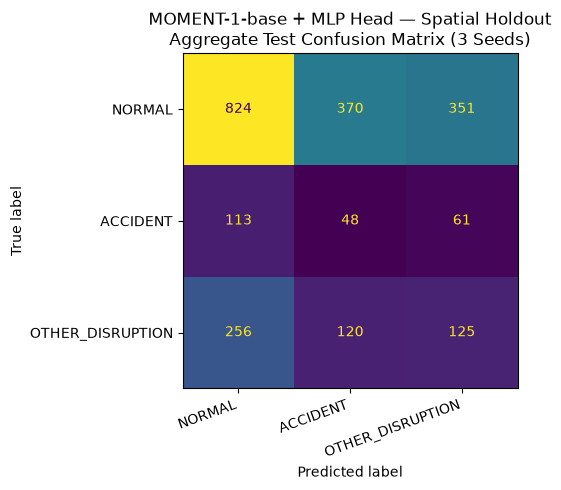

In [22]:

def aggregate_confusion(results):
    return np.sum(
        [
            result["confusion_matrix"]
            for result in results
        ],
        axis=0,
    )


cm_grouped = aggregate_confusion(
    all_results["grouped"]
)

cm_spatial = aggregate_confusion(
    all_results["spatial"]
)

print("Grouped-random:")
display(
    pd.DataFrame(
        cm_grouped,
        index=CLASS_ORDER,
        columns=CLASS_ORDER,
    )
)

print("Spatial holdout:")
display(
    pd.DataFrame(
        cm_spatial,
        index=CLASS_ORDER,
        columns=CLASS_ORDER,
    )
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm_spatial,
    display_labels=CLASS_ORDER,
)

display_cm.plot(
    ax=ax,
    values_format="d",
    colorbar=False,
)

ax.set_title(
    "MOMENT-1-base + MLP Head — Spatial Holdout\n"
    "Aggregate Test Confusion Matrix (3 Seeds)"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    "moment_base_mlp_spatial_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## 18. Export results

In [23]:

seed_results.to_csv(
    "moment_base_mlp_seed_results.csv",
    index=False,
)

summary_df.to_csv(
    "moment_base_mlp_overall_summary.csv",
    index=False,
)

per_class_df.to_csv(
    "moment_base_mlp_per_class_summary.csv",
    index=False,
)

print("Saved:")
print("- moment_base_mlp_seed_results.csv")
print("- moment_base_mlp_overall_summary.csv")
print("- moment_base_mlp_per_class_summary.csv")
print("- moment_base_mlp_spatial_confusion_matrix.png")


Saved:
- moment_base_mlp_seed_results.csv
- moment_base_mlp_overall_summary.csv
- moment_base_mlp_per_class_summary.csv
- moment_base_mlp_spatial_confusion_matrix.png



## Reporting note

Use the following model name in the paper:

**MOMENT-1-base (pretrained frozen encoder + supervised MLP head)**

This is a foundation-model representation-learning baseline rather than full end-to-end fine-tuning.

The benchmark remains comparable with the other Task 2 models because the dataset, labels,
7-hour observation window, input channels, split manifests, seeds, validation criterion,
test protocol, and primary metric remain unchanged.
